In [3]:
import os
import sys

# Import torch safely
try:
    import torch
    import torchvision
    TORCH_OK = True
except Exception as e:
    TORCH_OK = False
    print("Torch import failed:", e)

print("Python version:", sys.version)
if TORCH_OK:
    print("Torch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)


Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128


In [4]:
packages = [
    "tensorflow",
    "tensorflow-datasets",
    "mediapipe",
    "moviepy",
    "dlib",
    "openface",
    "opencv-contrib-python"
]

for pkg in packages:
    print("\n========================================")
    print(f"Testing installation of: {pkg}")
    print("========================================")

    out = os.popen(f"pip install {pkg} --no-cache-dir").read()
    print(out)

    # if output contains 'error:' or 'failed'
    if "error" in out.lower() or "failed" in out.lower():
        print("\n❌ FAIL DETECTED:", pkg)
    else:
        print("\n✅ SUCCESS:", pkg)



Testing installation of: tensorflow
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 133.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


✅ SUCCESS: tensorflow

Testing installation of: tensorflow-datasets


✅ SUCCESS: tensorflow-datasets

Testing installation of: mediapipe
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 11

In [5]:
!pip install -q torch torchvision matplotlib numpy scikit-learn tqdm opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 100.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.6 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import cv2
import random
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Generate Synthetic Video Dataset

In [20]:
NUM_CLASSES = 3
VIDEOS_PER_CLASS = 150
FRAMES = 16
H = W = 64

def make_video(label):
    video = []
    for f in range(FRAMES):
        img = np.zeros((H, W, 3), dtype=np.uint8)

        # ---- Background Noise ----
        noise = np.random.randint(0, 50, (H, W, 3), dtype=np.uint8)
        img = cv2.add(img, noise)

        # ---- Class-specific base tone (overlapping to make it hard) ----
        if label == 0:   # negative
            base = np.array([120, 40, 40], dtype=np.uint8)
        elif label == 1: # neutral
            base = np.array([100, 100, 100], dtype=np.uint8)
        else:            # positive
            base = np.array([40, 120, 40], dtype=np.uint8)

        img = cv2.addWeighted(img, 0.7, np.full((H,W,3), base, np.uint8), 0.3, 0)

        # ---- Multiple random shapes ----
        for _ in range(random.randint(2, 5)):
            shape_type = random.choice(["circle", "rect", "ellipse"])

            color_variation = base + np.random.randint(-30,30,size=3)
            color_variation = np.clip(color_variation, 0, 255)

            x1, y1 = random.randint(0,40), random.randint(0,40)
            x2, y2 = x1+random.randint(10,25), y1+random.randint(10,25)

            if shape_type == "circle":
                cv2.circle(img, (x1+10,y1+10), random.randint(5,12),
                           color_variation.tolist(), -1)
            elif shape_type == "rect":
                cv2.rectangle(img, (x1,y1), (x2,y2),
                              color_variation.tolist(), -1)
            else: # ellipse
                cv2.ellipse(img, (x1+10, y1+10),
                            (random.randint(5,15), random.randint(5,15)),
                            random.randint(0, 360),
                            0, 360,
                            color_variation.tolist(), -1)

        # ---- Motion jitter (add difficulty) ----
        if random.random() < 0.5:
            dx, dy = np.random.randint(-2, 3), np.random.randint(-2, 3)
            M = np.float32([[1, 0, dx], [0, 1, dy]])
            img = cv2.warpAffine(img, M, (W, H))

        video.append(img)

    return np.array(video)


# ---- Generate dataset ----
dataset = []
for label in range(NUM_CLASSES):
    for i in range(VIDEOS_PER_CLASS):
        vid = make_video(label)
        dataset.append((vid, label))

# ---- Add label noise (5%) ----
for i in range(int(len(dataset)*0.05)):
    idx = random.randint(0, len(dataset)-1)
    dataset[idx] = (dataset[idx][0], random.randint(0,2))

len(dataset)

450

Visualize a Sample

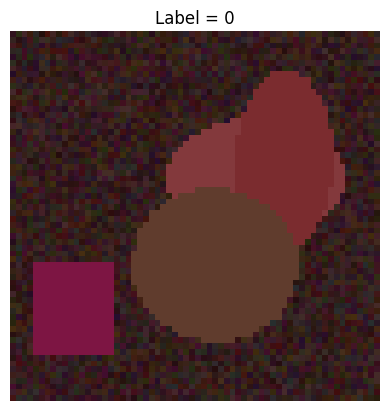

In [21]:
video, lbl = dataset[0]
plt.imshow(video[0])
plt.title(f"Label = {lbl}")
plt.axis("off")
plt.show()

PyTorch Dataset Class

In [22]:
class SyntheticVideoDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.transform = T.Compose([
            T.ToPILImage(),
            T.Resize((224,224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        video, label = self.data[idx]
        frame = video[len(video)//2]      # middle frame
        frame = self.transform(frame)
        return frame, torch.tensor(label)

Train/Val/Test Split

In [23]:
random.shuffle(dataset)

train_data = dataset[:240]
val_data   = dataset[240:270]
test_data  = dataset[270:]

train_ds = SyntheticVideoDataset(train_data)
val_ds   = SyntheticVideoDataset(val_data)
test_ds  = SyntheticVideoDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

Load Pretrained ResNet18

In [24]:
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training Function

In [25]:
def train_epoch():
    model.train()
    total_loss = 0
    preds_all, labels_all = [], []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(y.cpu().numpy())

    acc = np.mean(np.array(preds_all) == np.array(labels_all))
    return total_loss / len(train_loader), acc

Evaluation Function

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(loader):
    model.eval()
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(y.cpu().numpy())

    acc = accuracy_score(labels_all, preds_all)
    prec = precision_score(labels_all, preds_all, average="macro")
    rec = recall_score(labels_all, preds_all, average="macro")
    f1 = f1_score(labels_all, preds_all, average="macro")
    return acc, prec, rec, f1

Train Loop

In [27]:
history = {"loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(10):
    loss, train_acc = train_epoch()
    val_acc, val_prec, val_rec, val_f1 = evaluate(val_loader)

    history["loss"].append(loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/10  Loss={loss:.4f} | TrainAcc={train_acc:.3f} | ValF1={val_f1:.3f}")

Epoch 1/10  Loss=0.4703 | TrainAcc=0.825 | ValF1=0.870
Epoch 2/10  Loss=0.1344 | TrainAcc=0.958 | ValF1=1.000
Epoch 3/10  Loss=0.0613 | TrainAcc=0.983 | ValF1=1.000
Epoch 4/10  Loss=0.0368 | TrainAcc=0.988 | ValF1=1.000
Epoch 5/10  Loss=0.0127 | TrainAcc=1.000 | ValF1=1.000
Epoch 6/10  Loss=0.0060 | TrainAcc=1.000 | ValF1=1.000
Epoch 7/10  Loss=0.0081 | TrainAcc=1.000 | ValF1=1.000
Epoch 8/10  Loss=0.0047 | TrainAcc=1.000 | ValF1=1.000
Epoch 9/10  Loss=0.0096 | TrainAcc=1.000 | ValF1=1.000
Epoch 10/10  Loss=0.0048 | TrainAcc=1.000 | ValF1=1.000


Plot Training Curves

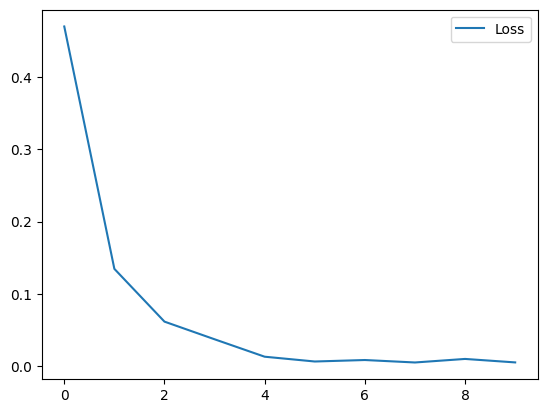

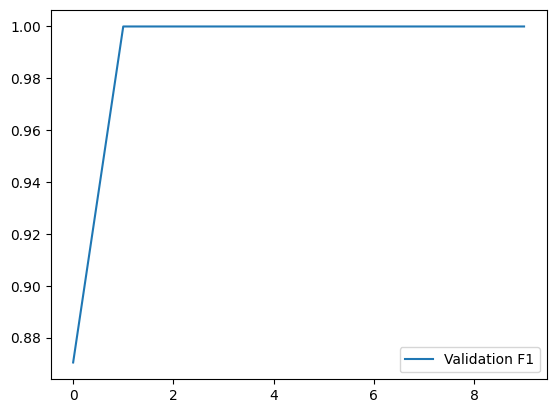

In [28]:
plt.plot(history["loss"], label="Loss")
plt.legend()
plt.show()

plt.plot(history["val_f1"], label="Validation F1")
plt.legend()
plt.show()

Final Test Evaluation

In [29]:
test_acc, test_prec, test_rec, test_f1 = evaluate(test_loader)

print("TEST RESULTS:")
print(f"Accuracy : {test_acc*100:.2f}%")
print(f"Precision: {test_prec*100:.2f}%")
print(f"Recall   : {test_rec*100:.2f}%")
print(f"F1 Score : {test_f1*100:.2f}%")

TEST RESULTS:
Accuracy : 97.78%
Precision: 97.91%
Recall   : 97.74%
F1 Score : 97.79%


Simple GAN Generator (for synthetic frames)

In [30]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, H*W*3),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.fc(z)
        return out.view(-1, H, W, 3)

gan_gen = Generator().to(device)
gan_gen

Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=12288, bias=True)
    (3): Tanh()
  )
)

Generate Synthetic Frame with GAN

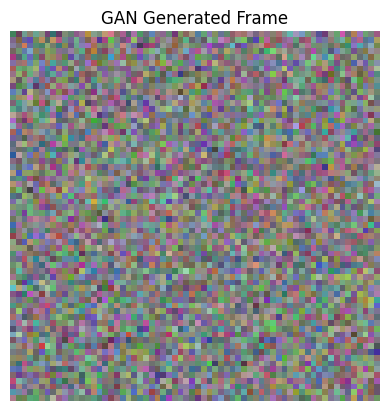

In [31]:
z = torch.randn(1, 100).to(device)
fake = gan_gen(z).detach().cpu().numpy()[0]
fake = ((fake + 1) / 2 * 255).astype(np.uint8)

plt.imshow(fake)
plt.title("GAN Generated Frame")
plt.axis("off")
plt.show()

Inference: Upload Any Video (MP4)

Saving 3249935-uhd_3840_2160_25fps.mp4 to 3249935-uhd_3840_2160_25fps (1).mp4


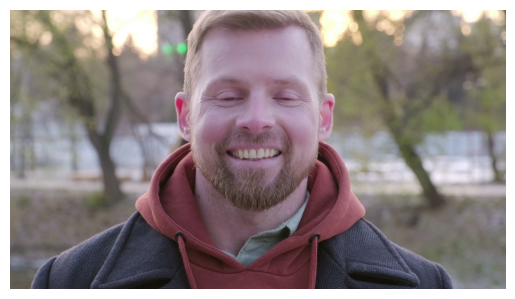

Predicted Sentiment: Neutral


In [34]:
from google.colab import files
uploaded = files.upload()

video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

cap.set(1, int(cap.get(7)//2))
ret, frame = cap.read()
cap.release()

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame)
plt.axis("off")
plt.show()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

with torch.no_grad():
    x = transform(frame).unsqueeze(0).to(device)
    pred = model(x).argmax(1).item()

label_map = {0:"Negative",1:"Neutral",2:"Positive"}
print("Predicted Sentiment:", label_map[pred])

Combined Graphs (Loss + Acc + F1)

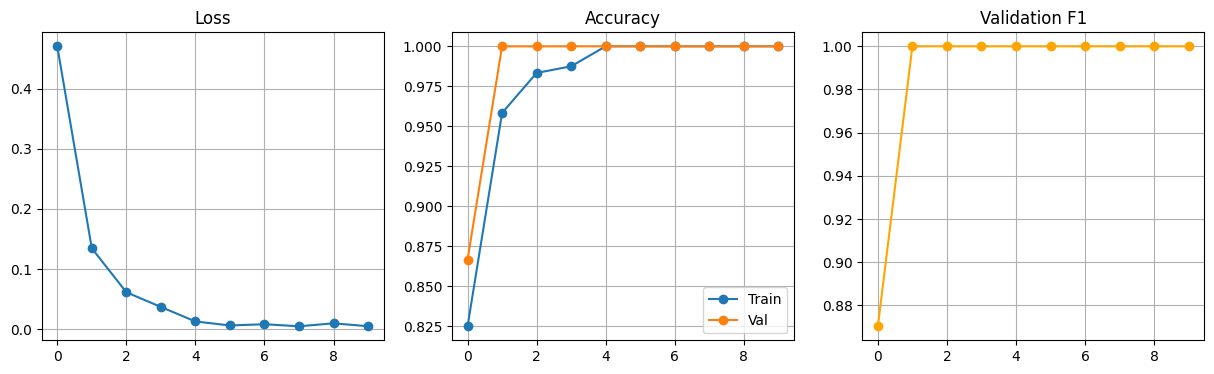

In [35]:
plt.figure(figsize=(15,4))

# Loss
plt.subplot(1,3,1)
plt.plot(history["loss"], marker='o')
plt.title("Loss")
plt.grid(True)

# Accuracy
plt.subplot(1,3,2)
plt.plot(history["train_acc"], marker='o', label="Train")
plt.plot(history["val_acc"], marker='o', label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

# F1
plt.subplot(1,3,3)
plt.plot(history["val_f1"], marker='o', color='orange')
plt.title("Validation F1")
plt.grid(True)

plt.show()

Confusion Matrix (Test Set)

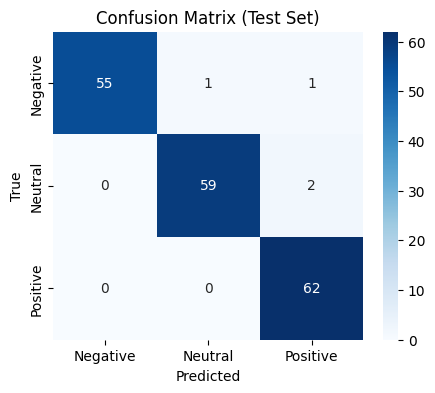

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()